In [1]:
import numpy as np
import pandas as pd
import markdown
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb


from pathlib import Path
import sys

sys.path.append(str(Path.cwd().parent))

from src.models.train_model import load_data, split_data,save_splitted_test_data, develop_model, get_models, save_models
from src.models.predict_model import run_prediction_evaluation, predict,get_predictions, get_evaluation_results, evaluate_model, get_feature_importance, get_r2_by_threshold, get_mae_by_threshold, get_mae_by_loadtype, get_mae_by_daytype
from src.visualization.visualize import plot_score_comparison_chart,plot_mae_baseline

sys.path.append('..')

%load_ext autoreload
%autoreload 2

# 1. Load Preprocessed Data


In [2]:
df = load_data()
df.head(3)

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,consumed_date,...,nsm_sin,nsm_cos,is_weekend,nsm_sin_loadtype,nsm_cos_loadtype,total_reactive,reactive_mode,pf_loss,electrical_load,near_unity_pf
0,3.17,2.95,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,2018-01-01 00:15:00,...,0.065403,0.997859,0,0.065403,0.997859,2.95,lagging_dominant,26.79,79.0305,1
1,4.00,4.46,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,2018-01-01 00:30:00,...,0.130526,0.991445,0,0.130526,0.991445,4.46,lagging_dominant,33.23,148.2058,1
2,3.24,3.28,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,2018-01-01 00:45:00,...,0.195090,0.980785,0,0.195090,0.980785,3.28,lagging_dominant,29.72,97.4816,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 24 columns):
 #   Column                                       Non-Null Count  Dtype         
---  ------                                       --------------  -----         
 0   Usage_kWh                                    35040 non-null  float64       
 1   Lagging_Current_Reactive.Power_kVarh         35040 non-null  float64       
 2   Leading_Current_Reactive_Power_kVarh         35040 non-null  float64       
 3   Lagging_Current_Power_Factor                 35040 non-null  float64       
 4   Leading_Current_Power_Factor                 35040 non-null  float64       
 5   NSM                                          35040 non-null  int64         
 6   WeekStatus                                   35040 non-null  str           
 7   Day_of_week                                  35040 non-null  str           
 8   Load_Type                                    35040 non-null  str           
 9   consum

# 2. Model Development

## 2.1 Check for time gaps
There must be no gap in the timeline, row N-1 must be exactly 15 minutes befor row N.

In [4]:
target = 'Usage_kWh'

# sort by time
df = df.sort_values('consumed_date').reset_index(drop=True)

# check for gaps
time_diff = df['consumed_date'].diff()
expected_time_freq = pd.Timedelta(minutes=15)
gaps = time_diff[time_diff != expected_time_freq].dropna()
print(f"Numbers of gaps: {len(gaps)}")

# build gaps and build lag features
df['usage_lag_1'] = df['Usage_kWh'].shift(1)      # previous 15-min reading
df['usage_lag_4'] = df['Usage_kWh'].shift(4)       # 1 hour ago
df['usage_rolling_mean_4'] = df['Usage_kWh'].shift(1).rolling(4).mean()
df['usage_rolling_std_4'] = df['Usage_kWh'].shift(1).rolling(4).std()


Numbers of gaps: 0


In [5]:
df.head(5)

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,consumed_date,...,nsm_cos_loadtype,total_reactive,reactive_mode,pf_loss,electrical_load,near_unity_pf,usage_lag_1,usage_lag_4,usage_rolling_mean_4,usage_rolling_std_4
0,3.42,3.46,0.0,70.30,100.0,0,Weekday,Monday,Light_Load,2018-01-01 00:00:00,...,1.000000,3.46,lagging_dominant,29.70,102.7620,1,NaN,NaN,NaN,NaN
1,3.17,2.95,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,2018-01-01 00:15:00,...,0.997859,2.95,lagging_dominant,26.79,79.0305,1,3.42,NaN,NaN,NaN
2,4.00,4.46,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,2018-01-01 00:30:00,...,0.991445,4.46,lagging_dominant,33.23,148.2058,1,3.17,NaN,NaN,NaN
3,3.24,3.28,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,2018-01-01 00:45:00,...,0.980785,3.28,lagging_dominant,29.72,97.4816,1,4.00,NaN,NaN,NaN
4,3.31,3.56,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,2018-01-01 01:00:00,...,0.965926,3.56,lagging_dominant,31.91,113.5996,1,3.24,3.42,3.4575,0.376685


As we expected, `usage_rolling_mean_4` needs 4 prior readings to compute an average, there simply is no ' 1 hour before '  there's no data before the start of this dataset.
`usage_lag_1` will have exactly 1 NaN (row 0 only). 
I decided to drop these 4 rows, given dataset is 35,040 rows total, losing 4 rows is completely negligible (0.01%). 

In [6]:
df = df.dropna(subset=['usage_lag_1', 'usage_lag_4', 'usage_rolling_mean_4', 'usage_rolling_std_4']).reset_index(drop=True)
df.head(5)

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,consumed_date,...,nsm_cos_loadtype,total_reactive,reactive_mode,pf_loss,electrical_load,near_unity_pf,usage_lag_1,usage_lag_4,usage_rolling_mean_4,usage_rolling_std_4
0,3.31,3.56,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,2018-01-01 01:00:00,...,0.965926,3.56,lagging_dominant,31.91,113.5996,1,3.24,3.42,3.4575,0.376685
1,3.82,4.50,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,2018-01-01 01:15:00,...,0.946930,4.50,lagging_dominant,35.28,158.7600,1,3.31,3.17,3.4300,0.384274
2,3.28,3.56,0.0,67.76,100.0,5400,Weekday,Monday,Light_Load,2018-01-01 01:30:00,...,0.923880,3.56,lagging_dominant,32.24,114.7744,1,3.82,4.00,3.5925,0.375000
3,3.60,4.14,0.0,65.62,100.0,6300,Weekday,Monday,Light_Load,2018-01-01 01:45:00,...,0.896873,4.14,lagging_dominant,34.38,142.3332,1,3.28,3.24,3.4125,0.273176
4,3.60,4.28,0.0,64.37,100.0,7200,Weekday,Monday,Light_Load,2018-01-01 02:00:00,...,0.866025,4.28,lagging_dominant,35.63,152.4964,1,3.60,3.31,3.5025,0.256174


## 2.2 Select Forecast-safe features

I exclude physical-leak features which are same-window electrical readings `Lagging_Current_Reactive.Power_kVarh_logged`, `Leading_Current_Reactive_Power_kVarh_logged`, `pf_loss`, `total_reactive`.

In [7]:
# all features = original + new
# features = ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
#        'Leading_Current_Reactive_Power_kVarh', 'Lagging_Current_Power_Factor',
#        'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week',
#        'Load_Type', 'consumed_date',
#        'Lagging_Current_Reactive.Power_kVarh_logged',
#        'Leading_Current_Reactive_Power_kVarh_logged', 'nsm_sin', 'nsm_cos',
#        'is_weekend', 'nsm_sin_loadtype', 'nsm_cos_loadtype', 'total_reactive',
#        'reactive_mode', 'pf_loss', 'electrical_load', 'near_unity_pf']

# forecast-safe features
features = ['nsm_sin', 'nsm_cos','nsm_sin_loadtype', 'nsm_cos_loadtype', 'is_weekend','electrical_load','usage_lag_1', 'usage_lag_4', 'usage_rolling_mean_4', 'usage_rolling_std_4']

num_cols = df[features].select_dtypes(include='number').columns.tolist()
cat_cols = df[features].select_dtypes(include=['str', 'category']).columns.tolist()

num_feature = [col for col in num_cols if col != target]
cat_feature = [col for col in cat_cols if col != target]

selected_features = num_feature + cat_feature



## 2.3 Split data to define test set

I decided to split by time(column - `consumed_date`) instead of randomly.
Test set will be the  most recent 'test size' fraction of the data so it represents genuiely unseen future period rather than time-adjacent neighbors of training data row.


In [9]:
# Split data
split_by_col = 'consumed_date'
test_size = 0.3

df_train, df_test = split_data(df,split_by_col,test_size)
print(f"Size of training dataset: {df_train.shape[0]} rows")
print(f"Size of test dataset: {df_test.shape[0]} rows")

X_train, y_train = df_train[selected_features], df_train[target]
X_test, y_test  = df_test[selected_features], df_test[target]

# Save splitted data
save_splitted_test_data(df_test,X_test, y_test)

Size of training dataset: 24525 rows
Size of test dataset: 10511 rows
Test dataset is successfully saved.


## 2.4 Model Training
- Base Model : Linear Regression
- Compare Model : Random Forest Regressor
- Compare Model 2 : XGBoost

In [10]:
model_pipelines = get_models(num_feature, cat_feature, X_train, y_train)

<class 'sklearn.linear_model._base.LinearRegression'>
<class 'sklearn.ensemble._forest.RandomForestRegressor'>
<class 'xgboost.sklearn.XGBRegressor'>


In [11]:
mdl_pipeline_lr, mdl_pipeline_rdf, mdl_pipeline_xgb = model_pipelines


# 3. Model Prediction and Evaluation

In [12]:
result_lr = run_prediction_evaluation(mdl_pipeline_lr['pipeline'], X_test, y_test)
result_rdf = run_prediction_evaluation(mdl_pipeline_rdf['pipeline'], X_test, y_test)
result_xgb = run_prediction_evaluation(mdl_pipeline_xgb['pipeline'], X_test, y_test)

# 4. Evaluation Score Comparison

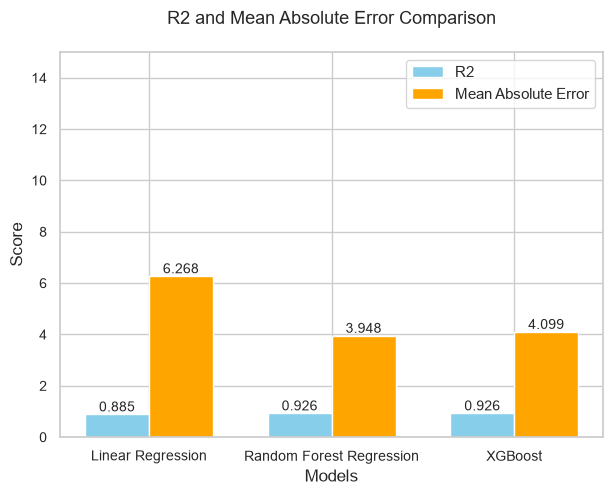

In [13]:
models = [ mdl_pipeline_lr['model'], mdl_pipeline_rdf['model'], mdl_pipeline_xgb['model']]
r2_list = [result_lr['R2'], result_rdf['R2'], result_xgb['R2']]
mae_list = [result_lr['MAE'],result_rdf['MAE'],result_xgb['MAE']]

plot_score_comparison_chart(models,r2_list, mae_list)


LinearRegression (R²=0.885, MAE=6.27) is clearly behind RF/XGB (R²≈0.926, MAE≈3.9–4.1) on both metrics — no KPI would plausibly change that ranking, so it's safe to drop at this stage without running the full KPI suite on it. That's the legitimate reason to do a lightweight R²/MAE comparison here: efficiency, not final judgment.

RF and XGBoost, being close on R²/MAE, both carry forward as finalists rather than picking one yet.

# 5. Finding the feature importance
I extract features names from the preprocessing steps to get feature importance.

## 5.1 Feature Importance in Random Forest Regressor

                feature  Importance
6           usage_lag_1    0.866785
5       electrical_load    0.075530
1               nsm_cos    0.016576
8  usage_rolling_mean_4    0.013758
9   usage_rolling_std_4    0.009520
3      nsm_cos_loadtype    0.009060
7           usage_lag_4    0.004122
0               nsm_sin    0.001841
2      nsm_sin_loadtype    0.001814
4            is_weekend    0.000992


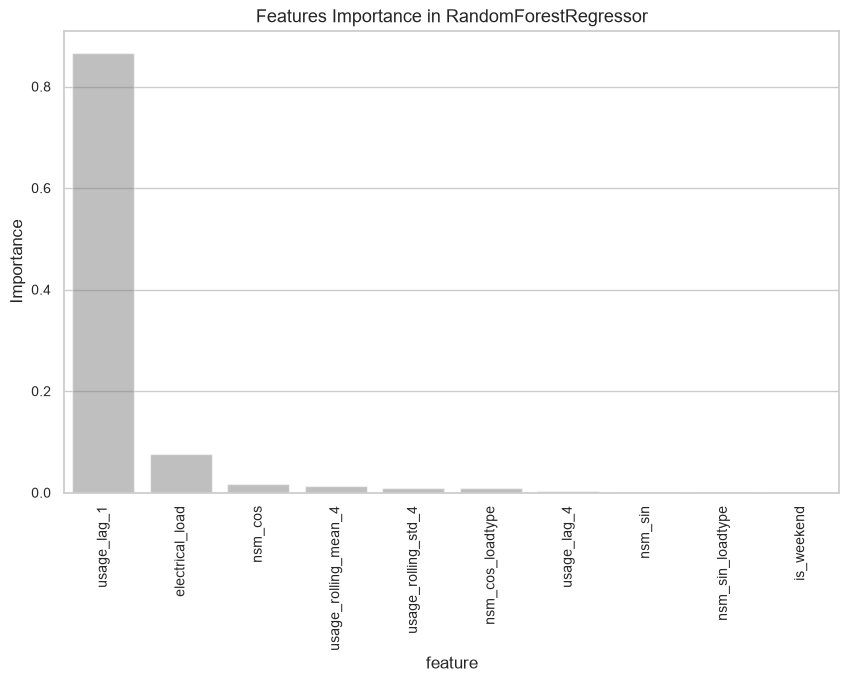

In [14]:

feature_importances_rdf = get_feature_importance(mdl_pipeline_rdf['pipeline'], mdl_pipeline_rdf['model'])

# 5.2 Feature Importance in XGBoost Regressor

                feature  Importance
6           usage_lag_1    0.816693
5       electrical_load    0.056938
1               nsm_cos    0.037937
3      nsm_cos_loadtype    0.024956
8  usage_rolling_mean_4    0.018705
9   usage_rolling_std_4    0.011909
0               nsm_sin    0.009553
4            is_weekend    0.009372
2      nsm_sin_loadtype    0.008180
7           usage_lag_4    0.005758


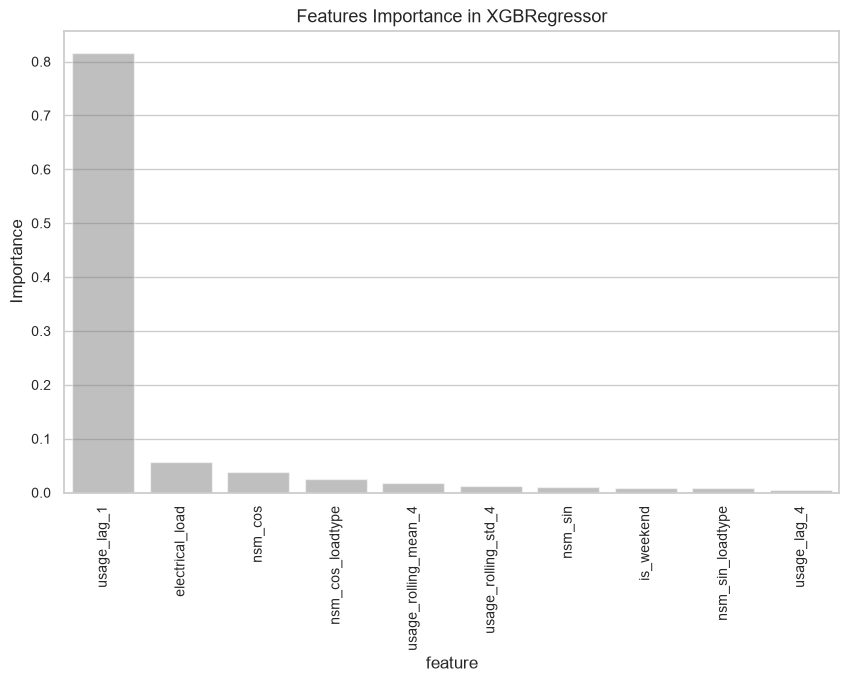

In [15]:
feature_importances_xgb = get_feature_importance(mdl_pipeline_xgb['pipeline'], mdl_pipeline_xgb['model'])

# 5.3 Importance Features

In [16]:
top_feature_rdf = pd.DataFrame(
    {'Model': mdl_pipeline_rdf['model'], 
     'Feature':feature_importances_rdf.iloc[:3]['feature'] }
     )

top_feature_xgb = pd.DataFrame(
    {'Model': mdl_pipeline_xgb['model'], 'Feature':feature_importances_xgb.iloc[:3]['feature'] }
    )

all_imp_features = pd.concat([top_feature_rdf, top_feature_xgb])

print(all_imp_features.to_markdown())

|    | Model                    | Feature         |
|---:|:-------------------------|:----------------|
|  6 | Random Forest Regression | usage_lag_1     |
|  5 | Random Forest Regression | electrical_load |
|  1 | Random Forest Regression | nsm_cos         |
|  6 | XGBoost                  | usage_lag_1     |
|  5 | XGBoost                  | electrical_load |
|  1 | XGBoost                  | nsm_cos         |


# 6. Save All Finalist Pipelines

In [17]:
# save model for prediction and evaluation
seleted_model_pipelines = [mdl_pipeline_rdf, mdl_pipeline_xgb]
save_models(seleted_model_pipelines)

Models successfully saved.


======================================

# 5. Evaluation By Business Requirement

Let's assume business context and thresholds are as following; 

**Business KPI Table**
| Metric | Business Meaning | Target/Threshold
| --- | --- | --- |
| R2  | Explains usage patterns using only forecast-safe (pre-consumption) features | >= 0.75
| MAE | Average prediction error, vs naive persistence baseline | ≥ 30% improvement over baseline
| MAE by Load_Type | Consistency of error across Light/Medium/Maximum load |  No class > 1.5× overall MAE
| MAE (weekday − weekend) | Error stability across day types | < 5 kWh




## 5.1 Evaluation - R2 >= Threshold 0.75

In [26]:

sla_threshold = 0.70
model_r2 = {'Model':models, 'R2':r2_list}
df_model_r2 = pd.DataFrame(model_r2)

# Finding model with R2 value that pass the predefined threshold
model_r2_threshold = get_r2_by_threshold(sla_threshold,df_model_r2)

model_r2_threshold

,Model,R2,Pass_Threshold
0,LinearRegression,0.8854,Pass
1,RandomForestRegressor,0.9261,Pass
2,XGBRegressor,0.9257,Pass


All three models pass R2 threshold KPI.

## 5.2 Evaluation - MAE ≥ 30% improvement over baseline

I calculate the baseline's MAE first, "naive persistence" just means predicting usage_lag_1 (last known value) as the forecast:

In [40]:
model_mae = {'Model':models, 'MAE': mae_list}
df_model_mae = pd.DataFrame(model_mae)

# Finding model with MAE value greater than or equal 30% improvement over baseline
df_model_mae_threshold = get_mae_by_threshold(df_model_mae, df_test)
df_model_mae_threshold

,Model,MAE,MAE_imprv_percent,MAE_Baseline
0,LinearRegression,6.2683,-15.7130,5.4171
1,RandomForestRegressor,3.9412,27.2453,5.4171
2,XGBRegressor,4.0995,24.3231,5.4171


It is most likely none of the three models' MAE has 30% improvement over baseline's MAE. But RandomForest regressor gives the highest MAE improvement.

## 5.3 Evaluation - MAE by Load_Type not more than 1.5 times of overall MAE

In [28]:

model_y_pred = {'Model' : models, 'y_pred' : [y_pred_linear, y_pred_rdf, y_pred_xgb]}
df_model_y_pred = pd.DataFrame(model_y_pred)
df_model_y_pred

,Model,y_pred
0,LinearRegression,"[47.7772720770441, 16.15118073943979, 11.06002..."
1,RandomForestRegressor,"[5.438883827962543, 6.176073645599681, 4.72789..."
2,XGBRegressor,"[2.732246, 5.687063, 4.502697, 5.3249755, 49.9..."


In [29]:
# Finding model with MAE by Load_Type not more than 1.5 times of overall MAE
overall_mae_threshold = 1.5

df_mae_loadtype_linear = get_mae_by_loadtype(models[0],y_pred_linear,df_test,target,overall_mae_threshold)
df_mae_loadtype_linear

,Model,Overall MAE,MAE_by_loadtype,Pass_Threshold (MAE by Load_Type<=Overall MAE * 1.5)
Load_Type,,,,
Light_Load,LinearRegression,6.268317,3.496920,True
Maximum_Load,LinearRegression,6.268317,9.621695,False
Medium_Load,LinearRegression,6.268317,9.392828,True


In [30]:
df_mae_loadtype_rdf = get_mae_by_loadtype(models[1],y_pred_rdf,df_test,target,overall_mae_threshold)
df_mae_loadtype_rdf

,Model,Overall MAE,MAE_by_loadtype,Pass_Threshold (MAE by Load_Type<=Overall MAE * 1.5)
Load_Type,,,,
Light_Load,RandomForestRegressor,3.941164,1.212639,True
Maximum_Load,RandomForestRegressor,3.941164,7.666466,False
Medium_Load,RandomForestRegressor,3.941164,6.700252,False


In [31]:
df_mae_loadtype_xgb = get_mae_by_loadtype(models[2],y_pred_xgb,df_test,target,overall_mae_threshold)
df_mae_loadtype_xgb

,Model,Overall MAE,MAE_by_loadtype,Pass_Threshold (MAE by Load_Type<=Overall MAE * 1.5)
Load_Type,,,,
Light_Load,XGBRegressor,4.099502,1.226775,True
Maximum_Load,XGBRegressor,4.099502,8.129971,False
Medium_Load,XGBRegressor,4.099502,6.923387,False


In [32]:
df_model_mae_loadtype = pd.concat([df_mae_loadtype_linear,df_mae_loadtype_rdf,df_mae_loadtype_xgb])
df_model_mae_loadtype

,Model,Overall MAE,MAE_by_loadtype,Pass_Threshold (MAE by Load_Type<=Overall MAE * 1.5)
Load_Type,,,,
Light_Load,LinearRegression,6.268317,3.496920,True
Maximum_Load,LinearRegression,6.268317,9.621695,False
Medium_Load,LinearRegression,6.268317,9.392828,True
Light_Load,RandomForestRegressor,3.941164,1.212639,True
Maximum_Load,RandomForestRegressor,3.941164,7.666466,False
Medium_Load,RandomForestRegressor,3.941164,6.700252,False
Light_Load,XGBRegressor,4.099502,1.226775,True
Maximum_Load,XGBRegressor,4.099502,8.129971,False
Medium_Load,XGBRegressor,4.099502,6.923387,False


Obviously, average MAE for Light_Load and Medium_Load in Linear Regression hit one of the KPI.

## 5.4 MAE by day type (weekday/weekend) less than 5 kWh

In [33]:
usage_threshold = 5
df_wk_linear = get_mae_by_daytype(models[0],y_pred_linear,df_test,target,usage_threshold)
df_wk_linear

,Model,Weekday MAE,Weekend MAE,MAE_gap_by_daytype,Pass_Threshold
0,LinearRegression,7.243013,3.908042,3.334971,True


In [34]:
df_wk_rdf = get_mae_by_daytype(models[1],y_pred_rdf,df_test,target,usage_threshold)
df_wk_rdf

,Model,Weekday MAE,Weekend MAE,MAE_gap_by_daytype,Pass_Threshold
0,RandomForestRegressor,4.838783,1.767535,3.071248,True


In [35]:
df_wk_xgb = get_mae_by_daytype(models[2],y_pred_xgb,df_test,target,usage_threshold)
df_wk_xgb

,Model,Weekday MAE,Weekend MAE,MAE_gap_by_daytype,Pass_Threshold
0,XGBRegressor,5.049348,1.799401,3.249947,True


In [36]:
df_model_wk =  pd.concat([df_wk_linear, df_wk_rdf, df_wk_xgb])
df_model_wk

,Model,Weekday MAE,Weekend MAE,MAE_gap_by_daytype,Pass_Threshold
0,LinearRegression,7.243013,3.908042,3.334971,True
0,RandomForestRegressor,4.838783,1.767535,3.071248,True
0,XGBRegressor,5.049348,1.799401,3.249947,True


For day type factor, average MAE for both weekday and weekend less than 5 kWh in all three models.

## 5.5 Evaluation Summary

In [ ]:

dic_eval_summary = {
    'Model': models,
    'MAE_ImprvOverBaseline': df_model_mae_threshold['MAE_imprv_pct'].to_numpy(),
    'MAE_GapByDayType': df_model_wk['MAE_gap_by_daytype'].to_numpy()
}

df_eval_summary = pd.DataFrame(dic_eval_summary)

print(df_eval_summary)

# plot_bar(df_eval_summary, 'Model', y, x_label, y_label, title)
df_model_mae_threshold


                   Model  MAE_ImprvOverBaseline  MAE_GapByDayType
0       LinearRegression               -15.7130          3.334971
1  RandomForestRegressor                27.2453          3.071248
2           XGBRegressor                24.3231          3.249947


,Model,MAE,MAE_imprv_pct,MAE_Baseline
0,LinearRegression,6.2683,-15.7130,5.4171
1,RandomForestRegressor,3.9412,27.2453,5.4171
2,XGBRegressor,4.0995,24.3231,5.4171


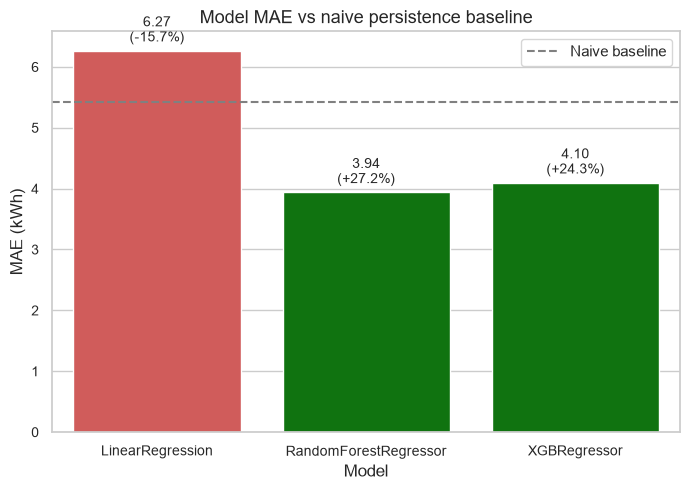

In [39]:
plot_mae_baseline(df_model_mae_threshold)